<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/aavso_variable_star_v5_robuste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Étoiles Variables — VSX + Finder Chart + Phase
### Sources : VizieR/CDS (Strasbourg) · DSS · SIMBAD

| Donnée | Source | Accès |
|--------|--------|-------|
| Métadonnées VSX (type, période, mag…) | **VizieR B/vsx** (CDS) | `astroquery.vizier` |
| Finder chart (image du ciel) | **DSS via SkyView** | `astroquery.skyview` |
| Étoiles de comparaison | **APASS DR9 via VizieR** | `astroquery.vizier` |
| Résolution de nom → coordonnées | **SIMBAD** | `astroquery.simbad` |

---
## 0. Installation

In [1]:

%pip install astroquery astropy matplotlib pillow --quiet
print("✅ Packages OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.6 MB/s eta 0:00:00
✅ Packages OK


---
## 1. Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.wcs import WCS
from astropy.io import fits

from astroquery.vizier  import Vizier
from astroquery.simbad  import Simbad
from astroquery.skyview import SkyView

Vizier.ROW_LIMIT = 5
print("✅ Imports OK")

✅ Imports OK


---
## 2. Paramètres  ← modifier ici

In [29]:

STAR_NAME      = "o cet"    # Nom GCVS/SIMBAD  (ex: "RR Lyr", "Mira", "SS Cyg", "T Cep")

CHART_FOV_DEG  = 1        # Champ en degrés  (0.25 | 0.5 | 1.0 | 2.0)
CHART_PIXELS   = 1200       # Résolution de l'image DSS
DSS_SURVEY     = "DSS2 Red" # "DSS2 Red" | "DSS2 Blue" | "DSS" | "2MASS-J"

COMP_MAGLIMIT  = 15.0       # Magnitude V limite pour les comp stars
COMP_BAND      = "Vmag"     # Bande APASS : Vmag | Bmag | r_mag | i_mag

print(f"🎯 {STAR_NAME}  —  FOV {CHART_FOV_DEG*60:.0f}'  —  {DSS_SURVEY}")

🎯 o cet  —  FOV 60'  —  DSS2 Red


---
## 3. Résolution des coordonnées (SIMBAD)

> **Note** : depuis astroquery ≥ 0.4.7 les noms de colonnes SIMBAD ont changé.  
> On utilise `SkyCoord.from_name()` qui est indépendant de la version.

In [30]:

print(f"🔍 Résolution de '{STAR_NAME}' via SIMBAD …")

ALIASES = {
    "g cas":"gamma Cas",
    "gamma cas":"gamma Cas",
    "o cet":"Mira",
    "omi cet":"Mira",
    "omicron cet":"Mira",
}

query_name = ALIASES.get(STAR_NAME.strip().lower(), STAR_NAME)

if query_name != STAR_NAME:
    print(f"ℹ️ Nom normalisé : {STAR_NAME} → {query_name}")

try:
    coord = SkyCoord.from_name(query_name)
except Exception as e:
    raise ValueError(
        f"Impossible de résoudre '{STAR_NAME}'. "
        "Essayez un nom SIMBAD (Mira, gamma Cas, RR Lyr...) "
        f"\nErreur originale: {e}"
    )

print(f"   AR  = {coord.ra.to_string(unit=u.hour, sep='hms', precision=2)}")
print(f"   Déc = {coord.dec.to_string(sep='dms', precision=1)}")
print(f"   (J2000 décimal : RA={coord.ra.deg:.5f}°  Dec={coord.dec.deg:.5f}°)")


🔍 Résolution de 'o cet' via SIMBAD …
ℹ️ Nom normalisé : o cet → Mira
   AR  = 2h19m20.79s
   Déc = -2d58m39.5s
   (J2000 décimal : RA=34.83663°  Dec=-2.97764°)


---
## 4. Données VSX via VizieR (catalogue B/vsx)

In [31]:
print(f"📋 Interrogation du catalogue VSX (B/vsx) sur VizieR …")

viz = Vizier(row_limit=5)
viz.columns = ['**']

# ── Recherche 1 : par nom dans VSX (plus fiable que le cône pour les alias) ──
vsx_by_name = Vizier(row_limit=5)
vsx_by_name.columns = ['**']
vsx_by_name.column_filters = {'Name': STAR_NAME}
vsx_name_results = vsx_by_name.query_constraints(catalog='B/vsx/vsx')

# ── Recherche 2 : par cône (fallback) ────────────────────────────────────────
vsx_cone_results = viz.query_region(coord, radius=5*u.arcmin, catalog='B/vsx/vsx')

# ── Sélection de la meilleure source ─────────────────────────────────────────
vsx_data = None
table    = None

if vsx_name_results and len(vsx_name_results) > 0 and len(vsx_name_results[0]) > 0:
    table = vsx_name_results[0]
    vsx_data = table[0]
    print(f"   ✅ Trouvé par nom exact dans VSX : {vsx_data['Name']}")
else:
    # Essai avec alias connus (Mira → o Cet, Algol → beta Per, etc.)
    ALIASES = {
        'MIRA'   : 'o Cet',
        'ALGOL'  : 'bet Per',
        'POLARIS': 'alf UMi',
        'DENEB'  : 'alf Cyg',
    }
    alias = ALIASES.get(STAR_NAME.strip().upper())
    if alias:
        vsx_by_name.column_filters = {'Name': alias}
        alt_results = vsx_by_name.query_constraints(catalog='B/vsx/vsx')
        if alt_results and len(alt_results) > 0 and len(alt_results[0]) > 0:
            table = alt_results[0]
            vsx_data = table[0]
            print(f"   ✅ Trouvé via alias '{alias}' : {vsx_data['Name']}")

    if vsx_data is None and vsx_cone_results and len(vsx_cone_results) > 0:
        table = vsx_cone_results[0]
        star_name_clean = STAR_NAME.strip().upper()
        for row in table:
            if star_name_clean in str(row['Name']).strip().upper():
                vsx_data = row
                print(f"   ✅ Trouvé par correspondance partielle : {vsx_data['Name']}")
                break
        if vsx_data is None:
            # Prendre la moins distante qui n'est pas CST (constante)
            for row in sorted(table, key=lambda r: float(r['_r'])):
                if str(row.get('Type', '')).strip() not in ('CST', 'DCEP?'):
                    vsx_data = row
                    print(f"   ⚠️  Fallback — étoile variable la plus proche : {vsx_data['Name']}")
                    break

VSX_TYPES = {
    'M'     : "Mira — géante rouge pulsante, amplitude >2.5 mag, P=100-700 j",
    'SR'    : "Semi-régulière — pulsations irrégulières, géante/supergéante",
    'SRA'   : "Semi-régulière A — géante froide, pulsations persistantes",
    'SRB'   : "Semi-régulière B — géante froide, pulsations mal définies",
    'SRC'   : "Semi-régulière C — supergéante froide (ex: Bételgeuse)",
    'SRD'   : "Semi-régulière D — géante/supergéante F, G ou K",
    'RR'    : "RR Lyrae — étoile de population II, P<1 j (amas globulaires)",
    'RRAB'  : "RR Lyrae type ab — courbe asymétrique, 0.3-1.2 j",
    'RRC'   : "RR Lyrae type c — courbe quasi-sinusoïdale, 0.2-0.5 j",
    'DCEP'  : "Céphéide classique (δ Cep) — supergéante, relation P-L",
    'DCEPS' : "Céphéide classique — mode fondamental court, P<8 j",
    'CW'    : "Céphéide W Virginis — population II",
    'CWA'   : "W Virginis — P>8 j",
    'CWB'   : "W Virginis — P<8 j",
    'EA'    : "Éclipsante Algol — éclipses distinctes, composantes sphériques",
    'EB'    : "Éclipsante Beta Lyr — transfert de masse, courbe continue",
    'EW'    : "Éclipsante W UMa — contact thermique, P<1 j",
    'UGSS'  : "Nova naine SS Cyg — éruptions récurrentes toutes les semaines/mois",
    'UG'    : "Nova naine — système binaire accrétant",
    'UGSU'  : "Nova naine SU UMa — super-éruptions + éruptions normales",
    'NL'    : "Nova-like — binaire serrée, transfert de masse persistant",
    'N'     : "Nova classique — explosion thermonucléaire sur naine blanche",
    'RCB'   : "R Coronae Borealis — chutes de magnitude imprévisibles (carbone)",
    'GCAS'  : "Gamma Cas — étoile Be, éjection d'enveloppe",
    'ZZ'    : "ZZ Ceti — naine blanche pulsante",
    'DSCT'  : "Delta Scuti — pulsante de la séquence principale, P<0.3 j",
    'GDOR'  : "Gamma Doradus — pulsations g-modes, P=0.3-3 j",
    'BY'    : "BY Draconis — taches stellaires, rotation",
    'RS'    : "RS CVn — binaire active, taches + éruptions",
    'ROT'   : "Rotationnelle — modulation par taches ou forme",
    'FUOR'  : "FU Orionis — étoile pré-séquence, éruption d'accrétion",
    'CST'   : "Constante — aucune variabilité détectée",
}

def get_type_description(type_str):
    if not type_str or type_str == '—':
        return '—'
    # Nettoyer les suffixes comme +, :, |
    key = type_str.strip().rstrip(':+|').split('+')[0].split('/')[0].upper()
    return VSX_TYPES.get(key, f"Type '{key}' — voir https://www.aavso.org/vsx/help/VariableStarTypeDesignations.pdf")

if vsx_data is None:
    print(f"❌ Aucune entrée VSX trouvée pour '{STAR_NAME}'.")
else:
    print(f"   Colonnes : {table.colnames}")

    def _s(row, *keys):
        for k in keys:
            if k in row.colnames:
                val = row[k]
                if hasattr(val, 'mask') and val.mask:
                    return '—'
                v = str(val).strip()
                return v if v not in ('', 'None', 'nan') else '—'
        return '—'

    fields = [
        ("Nom VSX",       _s(vsx_data, 'Name')),
        ("Type",          _s(vsx_data, 'Type')),
        ("Description",   get_type_description(_s(vsx_data, 'Type'))),
        ("Mag. max",      _s(vsx_data, 'max', 'Max')),
        ("Mag. min",      _s(vsx_data, 'min', 'Min')),
        ("Bande max",     _s(vsx_data, 'n_max', 'f_max')),
        ("Bande min",     _s(vsx_data, 'n_min', 'f_min')),
        ("Période (j)",   _s(vsx_data, 'Period')),
        ("Époque (JD)",   _s(vsx_data, 'Epoch')),
        ("Type spectral", _s(vsx_data, 'Sp', 'SpType')),
    ]
    w = max(len(k) for k, _ in fields) + 2
    print("\n" + "═"*52)
    print(f"  📋  VSX — {_s(vsx_data, 'Name')}")
    print("═"*52)
    for label, value in fields:
        if value != '—':
            print(f"  {label:<{w}}: {value}")
    print("═"*52)

📋 Interrogation du catalogue VSX (B/vsx) sur VizieR …
   ⚠️  Fallback — étoile variable la plus proche : omi Cet
   Colonnes : ['_r', 'recno', 'OID', 'Name', 'V', 'RAJ2000', 'DEJ2000', 'Type', 'l_max', 'max', 'u_max', 'n_max', 'f_min', 'l_min', 'min', 'u_min', 'n_min', 'Epoch', 'u_Epoch', 'l_Period', 'Period', 'u_Period', 'Sp', 'n_OID']

════════════════════════════════════════════════════
  📋  VSX — omi Cet
════════════════════════════════════════════════════
  Nom VSX        : omi Cet
  Type           : M
  Description    : Mira — géante rouge pulsante, amplitude >2.5 mag, P=100-700 j
  Mag. max       : 2.0
  Mag. min       : 10.1
  Bande max      : V
  Bande min      : V
  Période (j)    : 331.3
  Époque (JD)    : 2458457.0
  Type spectral  : M5e-M9e
════════════════════════════════════════════════════


---
## 5. Finder Chart — image DSS + étoiles de comparaison APASS

🖼️  Téléchargement DSS2 Red — FOV 60' …
   Tentative : DSS2 Red …
   ✅ Image OK : DSS2 Red
   Image : 1200×1200 px  —  WCS OK
⭐ Étoiles de comparaison APASS (Vmag ≤ 15.0) …
   80 étoiles APASS dans le champ.


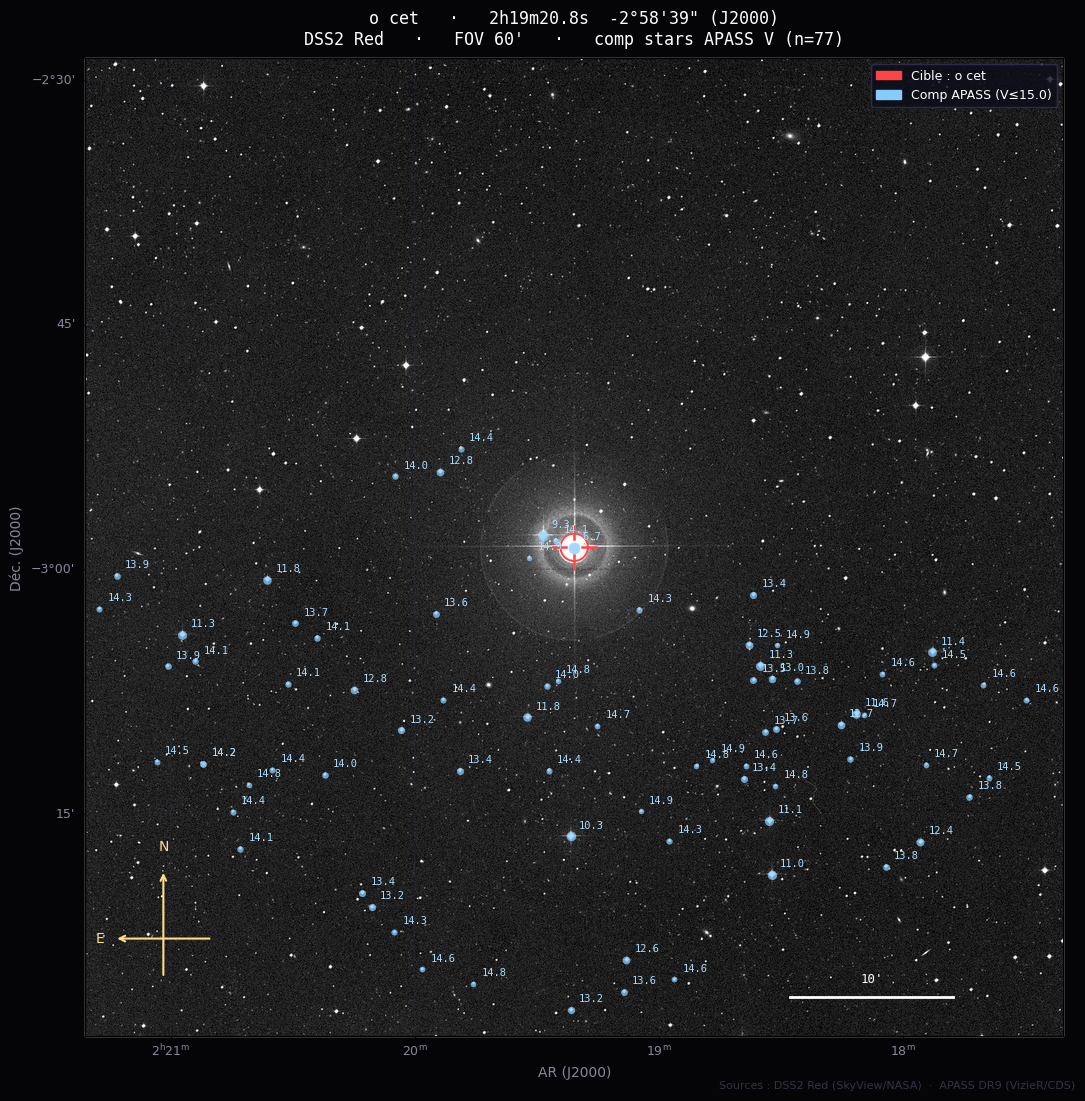


✅ Finder chart sauvegardée : finder_o_cet_FOV60arcmin.png


In [32]:
# ── 5a. Image DSS via SkyView ────────────────────────────────────────────────
print(f"🖼️  Téléchargement {DSS_SURVEY} — FOV {CHART_FOV_DEG*60:.0f}' …")

SURVEYS_FALLBACK = [DSS_SURVEY, "DSS2 Red", "DSS2 Blue", "DSS"]

hdu_list = None
used_survey = None

for survey in SURVEYS_FALLBACK:
    try:
        print(f"   Tentative : {survey} …")
        result = SkyView.get_images(
            position=coord,
            survey=[survey],
            width=CHART_FOV_DEG*u.deg,
            height=CHART_FOV_DEG*u.deg,
            pixels=CHART_PIXELS,
        )
        # Vérification explicite que le résultat contient bien un HDU
        if result and len(result) > 0 and result[0] is not None and len(result[0]) > 0:
            hdu_list    = result
            used_survey = survey
            print(f"   ✅ Image OK : {survey}")
            break
        else:
            print(f"   ⚠️  Résultat vide pour {survey}")
    except Exception as e:
        print(f"   ⚠️  Échec {survey} : {e}")

if hdu_list is None:
    raise RuntimeError("Aucun relevé DSS n'a retourné d'image. Vérifiez la connexion.")

hdu = hdu_list[0][0]
wcs = WCS(hdu.header)
img = hdu.data
print(f"   Image : {img.shape[1]}×{img.shape[0]} px  —  WCS OK")

# Mettre à jour DSS_SURVEY pour le titre de la chart
DSS_SURVEY = used_survey

# ── 5b. Étoiles de comparaison APASS DR9 ────────────────────────────────────
print(f"⭐ Étoiles de comparaison APASS ({COMP_BAND} ≤ {COMP_MAGLIMIT}) …")

apass_viz = Vizier(
    columns=['RAJ2000','DEJ2000','Vmag','e_Vmag','Bmag','r_mag','i_mag'],
    column_filters={COMP_BAND: f'<{COMP_MAGLIMIT}'},
    row_limit=80
)
apass_results = apass_viz.query_region(
    coord,
    radius=(CHART_FOV_DEG/2)*u.deg,
    catalog='II/336/apass9'
)

comp_stars = []
if apass_results and len(apass_results) > 0:
    for row in apass_results[0]:
        try:
            mag = float(row[COMP_BAND])
            comp_stars.append({
                'ra' : float(row['RAJ2000']),
                'dec': float(row['DEJ2000']),
                'mag': mag,
                'label': f"{mag:.1f}"
            })
        except (ValueError, TypeError):
            pass
    comp_stars.sort(key=lambda x: x['mag'])
    print(f"   {len(comp_stars)} étoiles APASS dans le champ.")
else:
    print("   Aucune étoile APASS trouvée.")

# ── 5c. Tracé matplotlib ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(11, 11), facecolor='#050508')
ax  = fig.add_subplot(111, projection=wcs)

vmin = np.percentile(img, 0.5)
vmax = np.percentile(img, 99.8)
img_clipped = np.clip(img, max(vmin, 1e-6), vmax)
ax.imshow(img_clipped, cmap='gray', origin='lower',
          norm=LogNorm(vmin=img_clipped.min(), vmax=img_clipped.max()),
          interpolation='lanczos')

# Réticule cible
pix = wcs.world_to_pixel(coord)
px, py = float(pix[0]), float(pix[1])
cross_r = CHART_PIXELS * 0.022
gap     = CHART_PIXELS * 0.008
for dx, dy in [(cross_r,0),(-cross_r,0),(0,cross_r),(0,-cross_r)]:
    sx = px + np.sign(dx)*gap if dx != 0 else px
    sy = py + np.sign(dy)*gap if dy != 0 else py
    ax.plot([sx, px+dx], [sy, py+dy],
            color='#ff4444', lw=1.8, transform=ax.get_transform('pixel'))
circle = plt.Circle((px, py), CHART_PIXELS*0.014,
                     color='#ff4444', fill=False, lw=1.4,
                     transform=ax.get_transform('pixel'), zorder=5)
ax.add_patch(circle)

# Comp stars APASS
comp_plotted = 0
for cs in comp_stars:
    c = SkyCoord(ra=cs['ra']*u.deg, dec=cs['dec']*u.deg)
    if c.separation(coord).deg > CHART_FOV_DEG * 0.49:
        continue
    cpx = wcs.world_to_pixel(c)
    cpx_x, cpx_y = float(cpx[0]), float(cpx[1])
    size = max(15, 120 - cs['mag'] * 7)
    ax.plot(cpx_x, cpx_y, 'o', ms=np.sqrt(size), color='#88ccff',
            alpha=0.75, mew=0, transform=ax.get_transform('pixel'), zorder=4)
    ax.annotate(cs['label'],
                xy=(cpx_x, cpx_y), xytext=(6, 6),
                textcoords='offset points',
                color='#aaddff', fontsize=7.5, fontfamily='monospace',
                transform=ax.get_transform('pixel'), zorder=6)
    comp_plotted += 1

# Axes WCS
ax.coords['ra'].set_axislabel('AR (J2000)',   color='#888899')
ax.coords['dec'].set_axislabel('Déc. (J2000)', color='#888899')
ax.coords['ra'].set_ticklabel(color='#888899',  fontsize=9)
ax.coords['dec'].set_ticklabel(color='#888899', fontsize=9)
ax.coords['ra'].set_ticks_position('b')
ax.coords['dec'].set_ticks_position('l')
ax.coords.grid(color='#2a2a3e', linestyle='--', alpha=0.5)

# Flèches N/E
arrow_kw = dict(arrowstyle='->', color='#ffdd88', lw=1.5)
ax.annotate('', xy=(0.08, 0.17), xytext=(0.08, 0.06),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=arrow_kw)
ax.text(0.08, 0.19, 'N', color='#ffdd88', fontsize=10,
        ha='center', transform=ax.transAxes)
ax.annotate('', xy=(0.03, 0.10), xytext=(0.13, 0.10),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=arrow_kw)
ax.text(0.015, 0.10, 'E', color='#ffdd88', fontsize=10,
        ha='center', va='center', transform=ax.transAxes)

# Barre d'échelle 10'
scale_deg  = 10/60
scale_pix  = (scale_deg / CHART_FOV_DEG) * CHART_PIXELS
bar_x0, bar_y0 = CHART_PIXELS*0.72, CHART_PIXELS*0.04
ax.plot([bar_x0, bar_x0+scale_pix], [bar_y0, bar_y0],
        color='white', lw=2, transform=ax.get_transform('pixel'))
ax.text(bar_x0 + scale_pix/2, bar_y0 + CHART_PIXELS*0.015, "10'",
        color='white', fontsize=9, ha='center', fontfamily='monospace',
        transform=ax.get_transform('pixel'))

# Titre

ra_str  = coord.ra.to_string(unit=u.hour, sep=('h', 'm', 's'), precision=1)
dec_str = coord.dec.to_string(sep=('°', "'", '"'), precision=0)

ax.set_title(
    f"{STAR_NAME}   ·   {ra_str}  {dec_str} (J2000)\n"
    f"{chosen_survey}   ·   FOV {CHART_FOV_DEG*60:.0f}'   ·   "
    f"comp stars APASS {COMP_BAND[:1]} (n={comp_plotted})",
    color='white', fontsize=12, fontfamily='monospace', pad=10
)

legend_elems = [
    mpatches.Patch(color='#ff4444', label=f'Cible : {STAR_NAME}'),
    mpatches.Patch(color='#88ccff', label=f'Comp APASS ({COMP_BAND[:1]}≤{COMP_MAGLIMIT})'),
]
ax.legend(handles=legend_elems, loc='upper right',
          facecolor='#0d0d1a', edgecolor='#333355',
          labelcolor='white', fontsize=9)

fig.text(0.99, 0.005,
         f"Sources : {chosen_survey} (SkyView/NASA)  ·  APASS DR9 (VizieR/CDS)",
         ha='right', color='#333344', fontsize=8)

fname = f"finder_{STAR_NAME.replace(' ','_')}_FOV{int(CHART_FOV_DEG*60)}arcmin.png"
plt.tight_layout()
plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"\n✅ Finder chart sauvegardée : {fname}")

---
## 6. Tableau des étoiles de comparaison

In [33]:
if comp_stars:
    print(f"  {'#':>3}  {'AR (J2000)':>16}  {'Déc. (J2000)':>17}  {COMP_BAND:>8}  Sep (')")
    print("  " + "-"*62)
    for i, cs in enumerate(comp_stars[:20], 1):
        c = SkyCoord(ra=cs['ra']*u.deg, dec=cs['dec']*u.deg)
        sep = c.separation(coord).arcmin
        ra_str  = c.ra.to_string(unit=u.hour,   sep=('h','m','s'), precision=1, pad=True)
        dec_str = c.dec.to_string(              sep=('°',"'",'"'), precision=0, alwayssign=True, pad=True)
        print(f"  {i:>3}  {ra_str:>16}  {dec_str:>17}  {cs['mag']:>8.2f}  {sep:>5.1f}")
else:
    print("Aucune comp star disponible.")

    #        AR (J2000)       Déc. (J2000)      Vmag  Sep (')
  --------------------------------------------------------------
    1       02h19m20.8s         -02°58'42"      6.74    0.0
    2       02h19m28.5s         -02°57'58"      9.34    2.0
    3       02h19m21.7s         -03°16'24"     10.27   17.7
    4       02h18m32.3s         -03°18'44"     10.96   23.4
    5       02h18m32.9s         -03°15'26"     11.11   20.6
    6       02h20m57.1s         -03°04'02"     11.29   24.6
    7       02h18m35.1s         -03°05'56"     11.35   13.5
    8       02h17m52.8s         -03°05'06"     11.40   22.9
    9       02h18m11.5s         -03°08'52"     11.63   20.1
   10       02h20m36.2s         -03°00'38"     11.76   18.9
   11       02h19m32.3s         -03°09'05"     11.80   10.8
   12       02h17m55.8s         -03°16'44"     12.40   27.9
   13       02h18m37.9s         -03°04'39"     12.54   12.3
   14       02h19m07.9s         -03°23'58"     12.61   25.5
   15       02h18m15.3s         -

---
## 7. (Optionnel) Courbe de lumière — AAVSO si accessible, sinon alternatives

In [35]:
import requests
import datetime
import pandas as pd
from io import StringIO

LC_DAYS = 600
LC_BAND = "V"
today    = datetime.date.today()
fromdate = (today - datetime.timedelta(days=LC_DAYS)).isoformat()

# ── Tentative 1 : AAVSO ──────────────────────────────────────────────────────
print("📡 Tentative AAVSO …")
observations = []
try:
    r = requests.get(
        "https://www.aavso.org/api/v1/observations/",
        params={"name": STAR_NAME, "fromdate": fromdate,
                "band": LC_BAND, "limit": 3000, "format": "json"},
        timeout=10
    )
    r.raise_for_status()
    raw = r.json()
    observations = raw.get("observations", raw) if isinstance(raw, dict) else raw
    source = "AAVSO"
    print(f"   ✅ {len(observations)} observations.")
except Exception as e:
    print(f"   ⚠️  Inaccessible ({type(e).__name__}) → tentative ASAS-SN …")

# ── Tentative 2 : ASAS-SN Sky Patrol via API ─────────────────────────────────
df_asassn = None
if not observations:
    try:
        # Résolution du nom → ra/dec déjà dans `coord`
        ra  = coord.ra.deg
        dec = coord.dec.deg

        # API ASAS-SN : recherche par coordonnées
        url_search = "https://asas-sn.ifa.hawaii.edu/skypatrol/api/input_list/"
        payload = {
            "ra_list"  : str(ra),
            "dec_list" : str(dec),
            "radius"   : "20",   # arcsec
        }
        r = requests.post(url_search, data=payload, timeout=20)
        r.raise_for_status()
        data = r.json()

        if data.get("stars"):
            star_id = data["stars"][0]["id"]
            print(f"   ASAS-SN star ID : {star_id}")

            # Téléchargement de la courbe de lumière CSV
            url_lc = f"https://asas-sn.ifa.hawaii.edu/skypatrol/api/lightcurve/{star_id}/"
            r2 = requests.get(url_lc, timeout=30)
            r2.raise_for_status()
            df_asassn = pd.read_csv(StringIO(r2.text))
            print(f"   ✅ {len(df_asassn)} points ASAS-SN récupérés.")
            print(f"   Colonnes : {df_asassn.columns.tolist()}")
        else:
            print("   ⚠️  Aucune étoile ASAS-SN dans un rayon de 20\".")
    except Exception as e:
        print(f"   ⚠️  ASAS-SN inaccessible ({type(e).__name__}: {e})")

# ── Tentative 3 : VizieR — catalogue ASAS-SN (II/366) ───────────────────────
if not observations and df_asassn is None:
    print("   Tentative VizieR ASAS-SN (II/366) …")
    try:
        viz_lc = Vizier(row_limit=5000)
        viz_lc.columns = ['**']
        lc_results = viz_lc.query_region(coord, radius=30*u.arcsec, catalog='II/366/catalog')
        if lc_results and len(lc_results) > 0 and len(lc_results[0]) > 0:
            tab = lc_results[0]
            print(f"   ✅ {len(tab)} points VizieR ASAS-SN.")
            jds  = [float(r['HJD']) for r in tab]
            mags = [float(r['mag']) for r in tab]
            observations = [{"JD": j, "magnitude": m} for j, m in zip(jds, mags)]
            source = "ASAS-SN via VizieR"
        else:
            print("   ⚠️  Aucun résultat VizieR ASAS-SN.")
    except Exception as e:
        print(f"   ⚠️  VizieR ASAS-SN échoué ({e})")

# ── Tracé ────────────────────────────────────────────────────────────────────
jds, mags = [], []

if observations:
    for o in observations:
        try:
            if o.get("magnitude"):
                jds.append(float(o["JD"]))
                mags.append(float(o["magnitude"]))
        except (ValueError, KeyError):
            pass
    source_label = source

elif df_asassn is not None:
    # Adapter selon les colonnes réelles (affichées ci-dessus)
    jd_col  = next((c for c in df_asassn.columns if 'hjd' in c.lower() or 'jd' in c.lower()), None)
    mag_col = next((c for c in df_asassn.columns if 'mag' in c.lower()), None)
    if jd_col and mag_col:
        df_clean = df_asassn.dropna(subset=[jd_col, mag_col])
        jds  = df_clean[jd_col].tolist()
        mags = df_clean[mag_col].tolist()
        source_label = "ASAS-SN Sky Patrol"

if jds:
    fig, ax = plt.subplots(figsize=(14, 5), facecolor="#050508")
    ax.set_facecolor("#050508")
    ax.scatter(jds, mags, s=7, color="#f5c842", alpha=0.8, linewidths=0)
    ax.invert_yaxis()
    ax.set_xlabel("Jour Julien (JD)", color="#aaaacc")
    ax.set_ylabel(f"Magnitude", color="#aaaacc")
    ax.set_title(
        f"Courbe de lumière — {STAR_NAME}  ({fromdate} → {today})",
        color="white", fontsize=12
    )
    ax.tick_params(colors="#888899")
    for sp in ax.spines.values():
        sp.set_color("#1a1a2a")
    fig.text(0.99, 0.01, f"Source : {source_label}",
             ha="right", color="#555566", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("\n❌ Aucune donnée disponible depuis toutes les sources.")
    print("   Accès manuel :")
    print(f"   • AAVSO LCG   : https://www.aavso.org/LCGv2/")
    print(f"   • ASAS-SN     : https://asas-sn.ifa.hawaii.edu/skypatrol/")
    print(f"   • ALeRCE (ZTF): https://alerce.online/")

📡 Tentative AAVSO …
   ⚠️  Inaccessible (HTTPError) → tentative ASAS-SN …
   ⚠️  ASAS-SN inaccessible (ConnectionError: HTTPSConnectionPool(host='asas-sn.ifa.hawaii.edu', port=443): Max retries exceeded with url: /skypatrol/api/input_list/ (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x784baff659a0>: Failed to establish a new connection: [Errno 113] No route to host')))
   Tentative VizieR ASAS-SN (II/366) …
   ⚠️  Aucun résultat VizieR ASAS-SN.

❌ Aucune donnée disponible depuis toutes les sources.
   Accès manuel :
   • AAVSO LCG   : https://www.aavso.org/LCGv2/
   • ASAS-SN     : https://asas-sn.ifa.hawaii.edu/skypatrol/
   • ALeRCE (ZTF): https://alerce.online/


# 8. Phase

---



📅 Date d'observation : 2026-05-18 22:30:00.000 UTC
   Jour Julien (JD)  : 2461179.43750

   Période      : 331.3000 jours
   Époque (JD)  : 2458457.0

════════════════════════════════════════════════
  🌟  Phase de o cet
════════════════════════════════════════════════
  Cycles écoulés  : 8.22
  Phase           : 0.2174  (78.3°)
  Prochaine phase 0 dans : 259.3 jours
════════════════════════════════════════════════


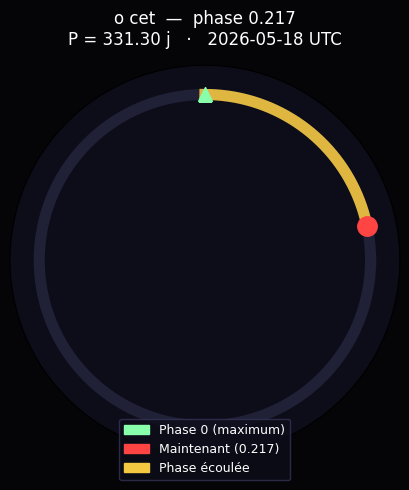

In [36]:
import datetime

# ╔══════════════════════════════════════════════════════════╗
# ║  ✏️  Date/heure d'observation (UTC)                     ║
# ╚══════════════════════════════════════════════════════════╝
OBS_DATETIME = "2026-05-18 22:30:00"   # format "YYYY-MM-DD HH:MM:SS" UTC
                                        # ou None pour utiliser maintenant

# ── Récupération période et époque depuis VSX ────────────────────────────────
def _f(row, *keys):
    for k in keys:
        if k in row.colnames:
            val = row[k]
            if hasattr(val, 'mask') and val.mask:
                return None
            try:
                return float(val)
            except (ValueError, TypeError):
                return None
    return None

period_days = _f(vsx_data, 'Period')  if vsx_data else None
epoch_jd    = _f(vsx_data, 'Epoch')   if vsx_data else None

# ── Conversion date → JD ─────────────────────────────────────────────────────
from astropy.time import Time

if OBS_DATETIME is None:
    t_obs = Time.now()
else:
    t_obs = Time(OBS_DATETIME, format='iso', scale='utc')

jd_obs = t_obs.jd

print(f"📅 Date d'observation : {t_obs.iso} UTC")
print(f"   Jour Julien (JD)  : {jd_obs:.5f}")

# ── Calcul de la phase ───────────────────────────────────────────────────────
if period_days is None or period_days <= 0:
    print("\n⚠️  Période non disponible dans VSX pour cette étoile.")
    print("   Renseigne manuellement :")
    print("   period_days = 309.95   # exemple pour R Leo")
    print("   epoch_jd    = 2444739.0")
else:
    print(f"\n   Période      : {period_days:.4f} jours")
    print(f"   Époque (JD)  : {epoch_jd}")

    if epoch_jd is None:
        print("\n⚠️  Époque non disponible — phase calculée depuis JD 2400000.0")
        epoch_jd = 2400000.0

    # Phase = partie fractionnaire de (JD_obs - Époque) / Période
    cycles = (jd_obs - epoch_jd) / period_days
    phase  = cycles % 1.0          # entre 0.0 et 1.0
    # Phase 0 = maximum (convention AAVSO pour les Mira)

    print(f"\n{'═'*48}")
    print(f"  🌟  Phase de {STAR_NAME}")
    print(f"{'═'*48}")
    print(f"  Cycles écoulés  : {cycles:.2f}")
    print(f"  Phase           : {phase:.4f}  ({phase*360:.1f}°)")
    print(f"  Prochaine phase 0 dans : "
          f"{(1 - phase) * period_days:.1f} jours")
    print(f"{'═'*48}")

    # ── Visualisation roue de phase ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(5, 5), facecolor='#050508',
                           subplot_kw=dict(polar=True))
    ax.set_facecolor('#0d0d1a')

    # Anneau de fond
    theta = np.linspace(0, 2*np.pi, 300)
    ax.plot(theta, np.ones(300)*0.85, color='#333355', lw=8, alpha=0.5)

    # Arc de phase écoulée
    theta_phase = np.linspace(np.pi/2, np.pi/2 - 2*np.pi*phase, 300)
    ax.plot(theta_phase, np.ones(300)*0.85, color='#f5c842', lw=8, alpha=0.9)

    # Marqueur de position actuelle
    angle_now = np.pi/2 - 2*np.pi*phase
    ax.plot(angle_now, 0.85, 'o', ms=14, color='#ff4444', zorder=5)

    # Marqueur de phase 0 (maximum)
    ax.plot(np.pi/2, 0.85, '^', ms=10, color='#88ffaa', zorder=5)

    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(f"{STAR_NAME}  —  phase {phase:.3f}\n"
                 f"P = {period_days:.2f} j   ·   {t_obs.iso[:10]} UTC",
                 color='white', fontsize=12, pad=15)

    legend_elems = [
        mpatches.Patch(color='#88ffaa', label='Phase 0 (maximum)'),
        mpatches.Patch(color='#ff4444', label=f'Maintenant ({phase:.3f})'),
        mpatches.Patch(color='#f5c842', label='Phase écoulée'),
    ]
    ax.legend(handles=legend_elems, loc='lower center',
              bbox_to_anchor=(0.5, -0.08),
              facecolor='#0d0d1a', edgecolor='#333355',
              labelcolor='white', fontsize=9)

    plt.tight_layout()
    plt.show()